## tl;dr

Checkpoint 250 is the recommended chk3 artifact. It has the minimum evaluation loss, passes all three frozen generation cases, and has the lowest mean and maximum repetition among loss-eligible, fully valid candidates.

## Context & Methods

### Key Assumptions

- The decision is limited to the saved checkpoints from the completed standalone chk1→chk3 run.
- Generation hard gates override loss: EOS, no cap, exactly one `</think>`, non-empty single-paragraph Minutes, exact numeric/date preservation, no strict periodic tail.
- Repetition limits are full 4-gram `<0.50`, tail `<0.60`, per-case increase vs chk1 `<=0.20`, and mean increase `<=0.10`.
- Loss-eligible checkpoints are within `0.001` eval loss of the run minimum.
- The three-case greedy probe is a regression gate, not a full semantic evaluation.

In [1]:
from pathlib import Path
import sys, json, hashlib
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/home/haobin_cui/research_files_space_2/fomc_trainer")
EXPECTED_PYTHON = "/home/haobin_cui/.conda/envs/fomc_trainer/bin/python"
assert sys.executable == EXPECTED_PYTHON, (sys.executable, EXPECTED_PYTHON)
RUN = ROOT / "output/training/retrain_v2/chk3_direct_chk1_cp200_full3ep_lr1e6_20260810/adapters/chk3"
PROBE = ROOT / "docs/summary/20260810T194621Z/chk3_direct_from_chk1/probe"
OUT = ROOT / "docs/summary/20260810T222112Z/chk3_checkpoint_selection"
print({"python": sys.executable, "pandas": pd.__version__})

{'python': '/home/haobin_cui/.conda/envs/fomc_trainer/bin/python', 'pandas': '2.2.3'}


## Data

The authoritative training source is `loss_history.jsonl`; generation evidence comes from the sealed redacted probe results for the same three sample IDs and decoding contract.

In [2]:
def read_jsonl(path):
    with path.open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

def sha256(path):
    h=hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024*1024), b""):
            h.update(chunk)
    return h.hexdigest()

loss_rows = read_jsonl(RUN / "loss_history.jsonl")
train = pd.DataFrame([{"step": int(r["step"]), "train_loss": float(r["train_loss"])} for r in loss_rows if r.get("train_loss") is not None])
evals = pd.DataFrame([{"step": int(r["step"]), "eval_loss": float(r["eval_loss"])} for r in loss_rows if r.get("eval_loss") is not None])
assert len(train) == 318 and len(evals) == 32
assert train.step.is_unique and evals.step.is_unique
print({"train_rows": len(train), "eval_rows": len(evals), "best_eval": evals.loc[evals.eval_loss.idxmin()].to_dict()})

{'train_rows': 318, 'eval_rows': 32, 'best_eval': {'step': 250.0, 'eval_loss': 1.1212036609649658}}


In [3]:
candidate_paths = {
    170: PROBE / "chk3_full_cp170_concurrent_v1/results.jsonl",
    200: PROBE / "chk3_full_cp200_selection_v1/results.jsonl",
    230: PROBE / "chk3_full_cp230_selection_v1/results.jsonl",
    250: PROBE / "chk3_full_cp250_selection_v1/results.jsonl",
    318: PROBE / "chk3_full_cp318_selection_v1/results.jsonl",
}
baseline_path = PROBE / "chk1_base_v2/results.jsonl"
baseline_rows = read_jsonl(baseline_path)
baseline_rep = {r["sample_id"]: float(r["full_token_4gram_repetition"]) for r in baseline_rows}
assert len(baseline_rows) == 3

best_eval = float(evals.eval_loss.min())
records=[]
case_records=[]
for cp,path in candidate_paths.items():
    rows=read_jsonl(path)
    assert len(rows)==3
    assert {r["sample_id"] for r in rows} == set(baseline_rep)
    eval_loss=float(evals.loc[evals.step==cp,"eval_loss"].iloc[0])
    valid=sum(bool(r["quality_valid"]) for r in rows)
    reps=[float(r["full_token_4gram_repetition"]) for r in rows]
    lengths=[int(r["raw_generated_tokens"]) for r in rows]
    deltas=[float(r["full_token_4gram_repetition"])-baseline_rep[r["sample_id"]] for r in rows]
    hard_pass = valid==3 and all(bool(r["hit_eos"]) and not bool(r["cap_reached"]) and int(r["think_boundary_count"])==1 and bool(r["final_answer_single_paragraph"]) and bool(r["numeric_multiset_preserved"]) and bool(r["date_set_preserved"]) and not bool(r["strict_periodic_tail"]) for r in rows)
    repetition_pass = max(reps)<0.50 and max(float(r["tail_token_4gram_repetition"]) for r in rows)<0.60 and max(deltas)<=0.20 and sum(deltas)/3<=0.10
    record={
        "checkpoint":cp,"eval_loss":eval_loss,"eval_delta_from_best":eval_loss-best_eval,
        "quality_valid_cases":valid,"hard_pass":hard_pass,"repetition_pass":repetition_pass,
        "mean_repetition":sum(reps)/3,"max_repetition":max(reps),
        "mean_repetition_delta_vs_chk1":sum(deltas)/3,"max_case_repetition_delta_vs_chk1":max(deltas),
        "mean_output_tokens":sum(lengths)/3,"min_output_tokens":min(lengths),"max_output_tokens":max(lengths),
        "loss_eligible":eval_loss-best_eval<=0.001,
        "results_sha256":sha256(path),
    }
    record["eligible"] = record["loss_eligible"] and hard_pass and repetition_pass
    records.append(record)
    for r in rows:
        case_records.append({
            "checkpoint":cp,"sample_id":r["sample_id"],"length_bucket":r["length_bucket"],
            "output_tokens":int(r["raw_generated_tokens"]),"quality_valid":bool(r["quality_valid"]),
            "repetition":float(r["full_token_4gram_repetition"]),
            "repetition_delta_vs_chk1":float(r["full_token_4gram_repetition"])-baseline_rep[r["sample_id"]],
            "date_preserved":bool(r["date_set_preserved"]),"numeric_preserved":bool(r["numeric_multiset_preserved"]),
            "failures":", ".join(r.get("quality_failures") or []),
        })
candidates=pd.DataFrame(records).sort_values("checkpoint").reset_index(drop=True)
cases=pd.DataFrame(case_records)
candidates

,checkpoint,eval_loss,eval_delta_from_best,quality_valid_cases,hard_pass,repetition_pass,mean_repetition,max_repetition,mean_repetition_delta_vs_chk1,max_case_repetition_delta_vs_chk1,mean_output_tokens,min_output_tokens,max_output_tokens,loss_eligible,results_sha256,eligible
0,170,1.128256,0.007053,3,True,True,0.209149,0.291295,0.083429,0.142017,808.333333,524,1001,False,967c10478c5d2459a0ef1a4f0b7b2f37bb45dd580f3ecd...,False
1,200,1.122187,0.000983,3,True,True,0.157576,0.175464,0.031855,0.046949,709.666667,441,983,True,5cc6da12a75e709512438033ab642622c8453a52c6340d...,True
2,230,1.121265,0.000061,2,False,True,0.177755,0.187204,0.052035,0.077140,646.000000,426,808,True,e2f8287bd40847a7a6c17843f16c76c0b37a308a3bcf37...,False
3,250,1.121204,0.000000,3,True,True,0.139282,0.173645,0.013562,0.035478,733.333333,421,963,True,c519ca6da29baa6bea3eb9e8cf7d11769ad6ea9f7710da...,True
4,318,1.121280,0.000076,3,True,True,0.141615,0.193133,0.015895,0.043855,610.666667,399,730,True,eabd2145e191034c9a14163d827e051ae198dceab992c0...,True


## Results

Evaluation loss plateaus after roughly step 220. Generation gates eliminate checkpoint 230 because one long case drops four source dates. Checkpoint 250 dominates the remaining candidates on eval loss and repetition.

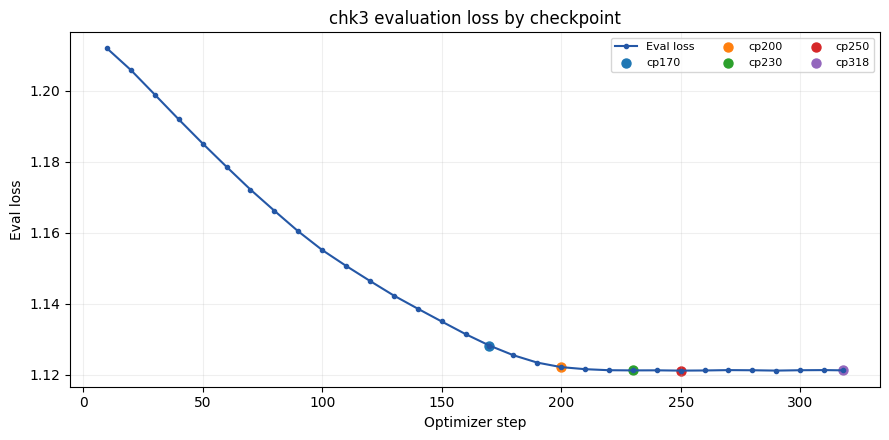

In [4]:
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(evals.step, evals.eval_loss, marker="o", markersize=3, linewidth=1.5, color="#2457A6", label="Eval loss")
for cp in candidate_paths:
    row=evals[evals.step==cp]
    ax.scatter(row.step,row.eval_loss,s=42,label=f"cp{cp}")
ax.set(title="chk3 evaluation loss by checkpoint", xlabel="Optimizer step", ylabel="Eval loss")
ax.grid(alpha=.2)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
display(candidates[["checkpoint","eval_loss","eval_delta_from_best","quality_valid_cases","mean_repetition","max_repetition","mean_output_tokens","eligible"]])
display(cases.pivot(index="length_bucket",columns="checkpoint",values=["output_tokens","repetition","quality_valid"]))

,checkpoint,eval_loss,eval_delta_from_best,quality_valid_cases,mean_repetition,max_repetition,mean_output_tokens,eligible
0,170,1.128256,0.007053,3,0.209149,0.291295,808.333333,False
1,200,1.122187,0.000983,3,0.157576,0.175464,709.666667,True
2,230,1.121265,0.000061,2,0.177755,0.187204,646.000000,False
3,250,1.121204,0.000000,3,0.139282,0.173645,733.333333,True
4,318,1.121280,0.000076,3,0.141615,0.193133,610.666667,True


output_tokens                     repetition            \
checkpoint              170  200  230  250  318        170       200   
length_bucket                                                          
long                   1001  983  808  963  730    0.15346  0.125638   
medium                  900  705  704  816  703   0.291295  0.175464   
short                   524  441  426  421  399   0.182692  0.171625   

                                            quality_valid                     \
checkpoint          230       250       318           170   200    230   250   
length_bucket                                                                  
long           0.180348  0.138686  0.110193          True  True  False  True   
medium         0.165714  0.173645  0.193133          True  True   True  True   
short          0.187204  0.105516  0.121519          True  True   True  True   

                     
checkpoint      318  
length_bucket        
long           True  
medium         True  
short          True

## Takeaways

- **Select checkpoint 250.** It is the global eval-loss minimum (`1.121203661`), passes all generation hard gates, and has the best mean/max repetition among eligible candidates.
- Checkpoint 230 is rejected despite near-identical loss because its long case omits four source dates.
- Checkpoint 318 is valid but has no loss advantage and slightly worse repetition than checkpoint 250.
- The choice is strong for regression safety but provisional for general semantic quality because the probe has only three greedy cases and persists no text.

In [6]:
eligible=candidates[candidates.eligible].copy()
selected=eligible.sort_values(["eval_loss","mean_repetition","checkpoint"]).iloc[0]
assert int(selected.checkpoint)==250
snapshot={
    "schema_version":"chk3-checkpoint-selection-analysis-v1",
    "status":"validated",
    "selected_checkpoint":250,
    "selection_rule":"hard generation gates, then eval loss within 0.001 of best, then repetition and earliest checkpoint as tie-breakers",
    "best_eval_loss":best_eval,
    "training":{
        "steps":318,"epochs":3,"train_rows":1683,"eval_rows":199,
        "loss_history_path":str((RUN/"loss_history.jsonl").relative_to(ROOT)),
        "loss_history_sha256":sha256(RUN/"loss_history.jsonl"),
    },
    "baseline":{
        "path":str(baseline_path.relative_to(ROOT)),"sha256":sha256(baseline_path),
        "mean_repetition":sum(baseline_rep.values())/3,
    },
    "candidates":candidates.to_dict(orient="records"),
    "cases":cases.to_dict(orient="records"),
    "eval_curve":evals.to_dict(orient="records"),
    "limitations":[
        "three deterministic greedy cases only",
        "completion text is redacted, so non-numeric factuality, causality, and style were not manually reviewed",
        "standalone direct chk1-to-chk3 run is non-promotable under the canonical DAG",
    ],
}
out_path=OUT/"analysis_snapshot.json"
out_path.write_text(json.dumps(snapshot,ensure_ascii=False,indent=2,sort_keys=True)+"\n",encoding="utf-8")
print({"selected_checkpoint":250,"snapshot":str(out_path),"snapshot_sha256":sha256(out_path)})

{'selected_checkpoint': 250, 'snapshot': '/home/haobin_cui/research_files_space_2/fomc_trainer/docs/summary/20260810T222112Z/chk3_checkpoint_selection/analysis_snapshot.json', 'snapshot_sha256': 'a54d452b26202a5788dfc2ac7e90be24ea986421dae6efd11f1782af6da5f390'}
